In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf

In [3]:
directory = "data"
names = "an2i  at33  boland  bpm  ch4f  cheyer  choon  danieln  glickman  karyadi  kawamura  kk49  megak  mitchell  night  phoebe  saavik  steffi  sz24  tammo".split()
poses = "left right straight up".split()
expressions = "angry happy neutral sad".split()
eyes = "sunglasses open".split()

names_dict = dict(zip(names, [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]))
poses_dict = dict(zip(poses, [0,1,2,3]))
expressions_dict = dict(zip(expressions, [0,1,2,3]))
eyes_dict = dict(zip(eyes, [0, 1]))

def return_path(n,p,e,y):
    return directory+"/"+names[n]+"/"+names[n]+"_"+poses[p]+"_"+expressions[e]+"_"+eyes[y]+".pgm"

def load_image(n,p,e,y):
    return imread(return_path(n,p,e,y))

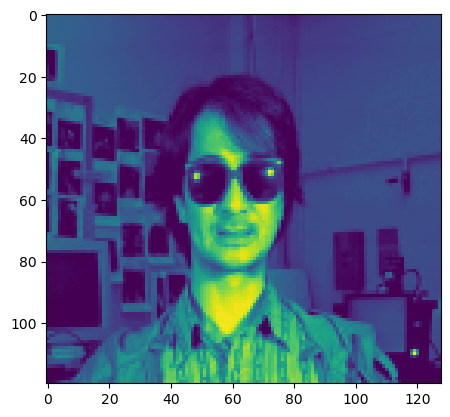

In [4]:
test_image = load_image(names_dict['kawamura'],poses_dict['straight'], expressions_dict['angry'], eyes_dict['sunglasses'])
plt.imshow(test_image)

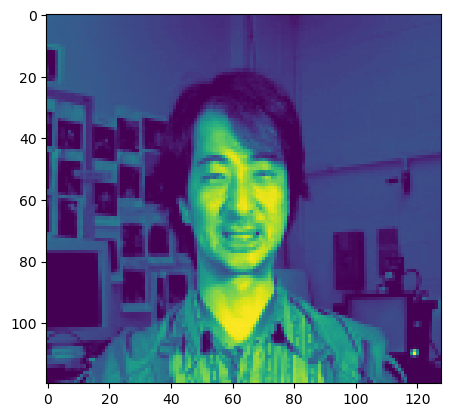

In [5]:
test_image = load_image(names_dict['kawamura'],poses_dict['straight'], expressions_dict['angry'], eyes_dict['open'])
plt.imshow(test_image)

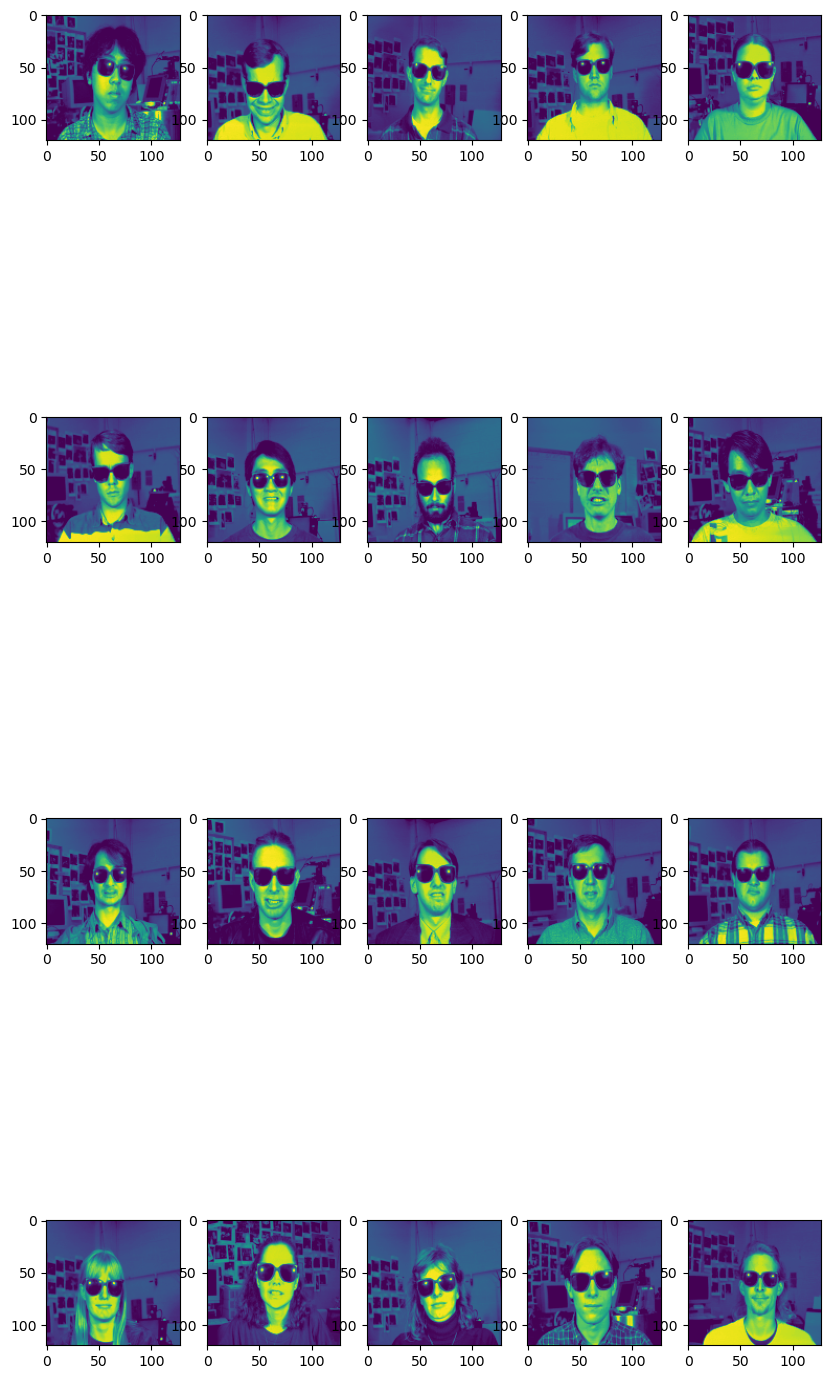

In [6]:
plt.figure(figsize=(10,20))
for i in range(1,21):
    plt.subplot(4,5,i)
    test_image = load_image(i-1,poses_dict['straight'], expressions_dict['angry'], eyes_dict['sunglasses'])
    plt.imshow(test_image)

In [7]:
gender = ["male","male","male","male","female",
          "male","male","male","male","male",
          "male","male","male","male","male",
          "female","female","female","male","male"]

In [8]:
X = []
Y = []

for n in np.arange(len(names)):
    for p in np.arange(len(poses)):
        for e in np.arange(len(expressions)):
            for y in np.arange(len(eyes)):
                try:
                    X = X + [load_image(n,p,e,y)/255.0]
                    Y = Y + [gender[n]+"-"+poses[p]+"-"+eyes[y]]
                except:
                    print(f"{return_path(n,p,e,y)} not found!")

X = np.array(X)

encoder = LabelBinarizer()
encoder.fit(Y)
Y = encoder.transform(Y)

data/choon/choon_left_angry_sunglasses.pgm not found!
data/danieln/danieln_straight_happy_sunglasses.pgm not found!
data/glickman/glickman_right_sad_open.pgm not found!
data/glickman/glickman_straight_angry_open.pgm not found!
data/karyadi/karyadi_right_happy_sunglasses.pgm not found!
data/kawamura/kawamura_up_happy_open.pgm not found!
data/megak/megak_straight_sad_sunglasses.pgm not found!
data/megak/megak_up_sad_sunglasses.pgm not found!
data/mitchell/mitchell_right_angry_sunglasses.pgm not found!
data/mitchell/mitchell_straight_angry_open.pgm not found!
data/mitchell/mitchell_up_happy_sunglasses.pgm not found!
data/mitchell/mitchell_up_neutral_sunglasses.pgm not found!
data/phoebe/phoebe_left_angry_open.pgm not found!
data/sz24/sz24_left_neutral_sunglasses.pgm not found!
data/tammo/tammo_right_happy_open.pgm not found!
data/tammo/tammo_right_sad_open.pgm not found!


In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=42)

In [10]:
# augment training data
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=10, width_shift_range=0.10, height_shift_range=0.10, zoom_range=0.1,fill_mode='nearest')

X_train_augmented = []
Y_train_augmented = []

for n in range(X_train.shape[0]):
    img = X_train[n]
    imgclass = Y_train[n]
    
    X_train_augmented = X_train_augmented + [img]
    Y_train_augmented = Y_train_augmented + [imgclass]

    img_4D = img.reshape((1,) + img.shape + (1,))
    
    img_copies = []
    for el in datagen.flow(img_4D, batch_size=1):
         img_copies.append(np.squeeze(el))
                        
         # add 9 copies
         if len(img_copies) >= 9:
            break
                    
    for el in img_copies:
        X_train_augmented = X_train_augmented + [el]
        Y_train_augmented = Y_train_augmented + [imgclass]
        

X_train = np.array(X_train_augmented)
Y_train = np.array(Y_train_augmented)

In [11]:
X.shape

(624, 120, 128)

In [12]:
X[0].shape

(120, 128)

In [13]:
Y.shape

(624, 16)

In [14]:
Y[0].shape

(16,)

In [15]:
X_train.shape

(4050, 120, 128)

In [16]:
Y_train.shape

(4050, 16)

Text(0.5, 1.0, 'male-left-open')

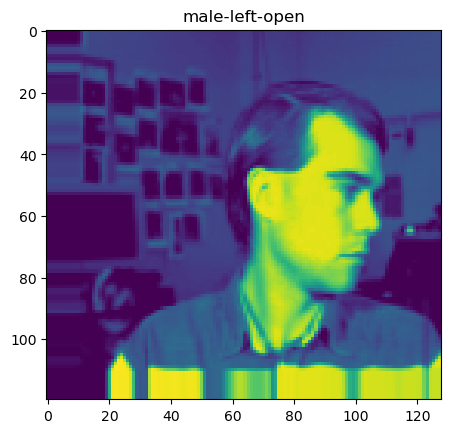

In [17]:
myn = 27
plt.imshow(X_train[myn])
plt.title(encoder.inverse_transform(Y_train)[myn])

Text(0.5, 1.0, 'male-left-open')

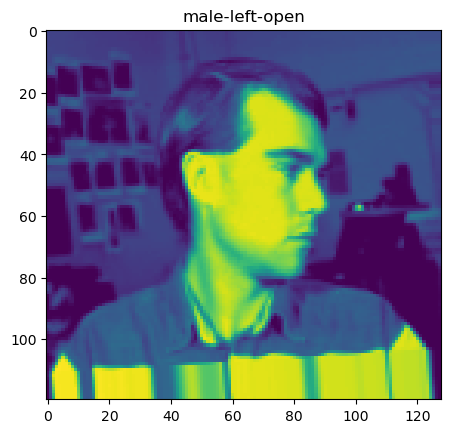

In [18]:
myn = 28
plt.imshow(X_train[myn])
plt.title(encoder.inverse_transform(Y_train)[myn])

In [19]:
lreg = 1.0e-5

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(120,128,1)))

model.add(tf.keras.layers.Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lreg), bias_regularizer=tf.keras.regularizers.l2(lreg)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lreg), bias_regularizer=tf.keras.regularizers.l2(lreg)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lreg), bias_regularizer=tf.keras.regularizers.l2(lreg)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))

model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lreg), bias_regularizer=tf.keras.regularizers.l2(lreg)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(3, 4)))

model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lreg), bias_regularizer=tf.keras.regularizers.l2(lreg)))

model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(16, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 128, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,472 (107.31 KB)

 Trainable params: 27,472 (107.31 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
model.fit(X_train, Y_train, batch_size=64, epochs=100, validation_data=(X_test, Y_test),callbacks=[early_stop])

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.1001 - loss: 2.7208 - val_accuracy: 0.1553 - val_loss: 2.6808
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.1363 - loss: 2.5729 - val_accuracy: 0.2557 - val_loss: 2.5081
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.1877 - loss: 2.3900 - val_accuracy: 0.2740 - val_loss: 2.4235
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.2205 - loss: 2.2810 - val_accuracy: 0.2283 - val_loss: 2.2457
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.2253 - loss: 2.2231 - val_accuracy: 0.2831 - val_loss: 2.2036
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.2431 - loss: 2.1247 - val_accuracy: 0.2420 - val_loss: 2.0665
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.2478 - loss: 2.0597 - val_accuracy: 0.3470 - val_loss: 1.9573
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.2916 - loss: 1.9812 - val_accuracy

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.8611 - loss: 0.3992 - val_accuracy: 0.9863 - val_loss: 0.0886
Epoch 52/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8577 - loss: 0.4014 - val_accuracy: 0.9726 - val_loss: 0.0928
Epoch 53/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.8685 - loss: 0.4042 - val_accuracy: 0.9726 - val_loss: 0.0882
Epoch 54/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8525 - loss: 0.4284 - val_accuracy: 0.9680 - val_loss: 0.0966
Epoch 55/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.8555 - loss: 0.4204 - val_accuracy: 0.9726 - val_loss: 0.0911
Epoch 56/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8663 - loss: 0.3927 - val_accuracy: 0.9772 - val_loss: 0.0825
Epoch 57/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8710 - loss: 0.3788 - val_accuracy: 0.9772 - val_loss: 0.0789
Epoch 58/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8792 - loss: 0.3624 - val_accuracy: 0.

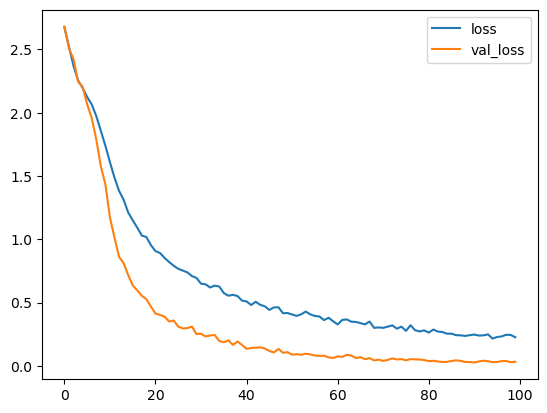

In [22]:
plt.plot(model.history.history['loss'], label='loss')
plt.plot(model.history.history['val_loss'], label='val_loss')
plt.legend()

In [23]:
Y_pred=model.predict(X_test)
Y_pred=np.array([(el==el[np.argmax(el)]).astype(int) for el in Y_pred])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [24]:
print("\nClassification Report:\n\n", classification_report(Y_test, Y_pred))


Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         7
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       1.00      1.00      1.00        23
          12       1.00      1.00      1.00        27
          13       0.97      1.00      0.98        28
          14       1.00      1.00      1.00        18
          15       1.00      0.95      0.98        21

   micro avg       1.00      1.00      1.00       219


In [25]:
accuracy_score(Y_test, Y_pred)

0.9954337899543378

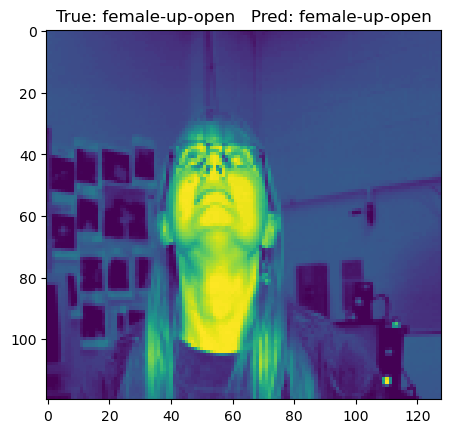

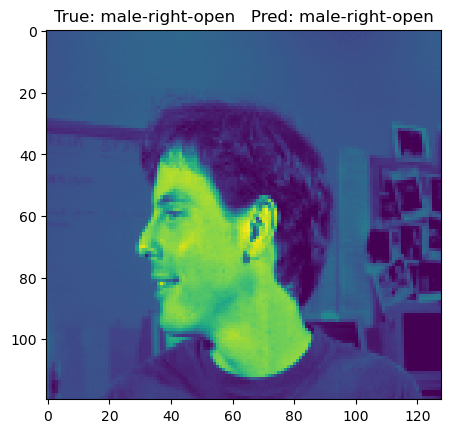

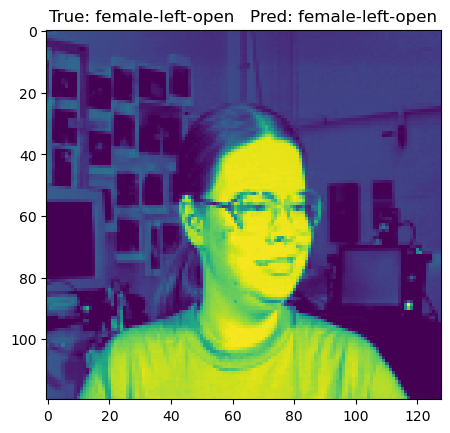

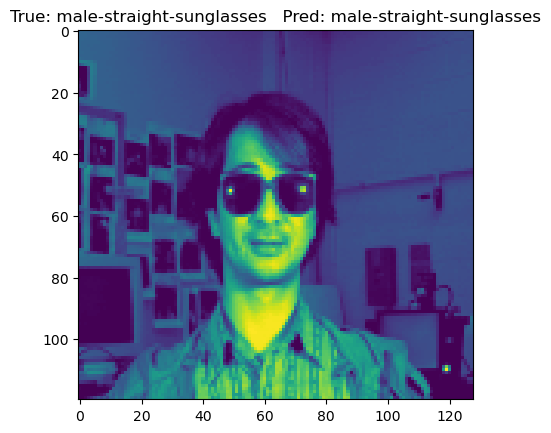

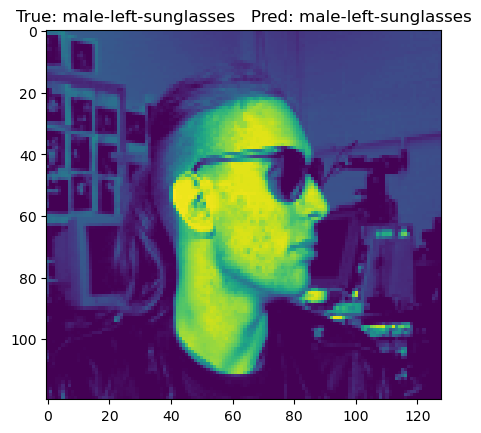

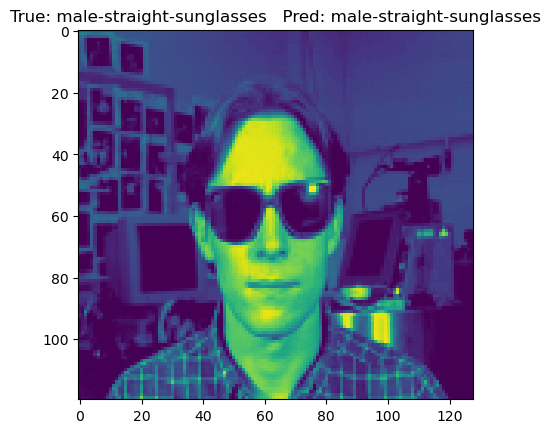

In [26]:
for myn in [1, 10, 20, 30, 40, 60]:
    plt.figure()
    plt.imshow(X_test[myn])
    plt.title(f"True: {encoder.inverse_transform(Y_test)[myn]}   Pred: {encoder.inverse_transform(Y_pred)[myn]}")